K-Nearest Neighbours · Naive Bayes · Feature Scaling

 K-Nearest Neighbours (KNN)

KNN is a simple machine learning algorithm that classifies a new data point based on the majority class of its nearest neighbors. It calculates distance (like Euclidean distance) and picks the K closest points. It is easy to use but can be slow for large datasets.

 Naive Bayes

Naive Bayes is a probabilistic algorithm based on Bayes’ theorem. It assumes that all features are independent of each other (which is “naive”). It works very well for text classification like spam detection and is fast and efficient.

Feature Scaling

Feature scaling is the process of bringing all features to a similar range (like 0 to 1 or standard scale). It is important for algorithms like KNN, SVM, and Gradient Descent because they depend on distance or magnitude. Without scaling, large-valued features can dominate.

Statistical Methods for Selecting k

Cross-Validation: Cross-Validation is a good way to find the best value of k is by using k-fold cross-validation. This means dividing the dataset into k parts. The model is trained on some of these parts and tested on the remaining ones. This process is repeated for each part. The k value that gives the highest average accuracy during these tests is usually the best one to use.


| k | Average Accuracy |
| - | ---------------- |
| 1 | 88%              |
| 3 | 91%              |
| 5 | 94%              |
| 7 | 93%              |
| 9 | 92%              |


In [3]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.datasets import load_iris

# Load the Iris dataset as an example
iris = load_iris()
X = iris.data
y = iris.target

for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(model, X, y, cv=5)

    print(k, scores.mean())

1 0.96
2 0.9466666666666665
3 0.9666666666666668
4 0.9733333333333334
5 0.9733333333333334
6 0.9800000000000001
7 0.9800000000000001
8 0.9666666666666668
9 0.9733333333333334
10 0.9800000000000001
11 0.9800000000000001
12 0.9800000000000001
13 0.9733333333333334
14 0.9666666666666666
15 0.9666666666666668
16 0.9666666666666668
17 0.9666666666666668
18 0.9666666666666666
19 0.9666666666666668
20 0.96


KNN Implementation

In [4]:
import numpy as np
from collections import Counter
class KNNClassifier:
  def __init__(self, k=3):
    self.k = k
  def fit(self, X, y):
    self.X_train = np.array(X)
    self.y_train = np.array(y)
  def _euclidean(self, a, b):
    return np.sqrt(np.sum((a - b) ** 2))
  def predict_one(self, x):
    dists = []
    for xt in self.X_train:
      dists.append(
      self._euclidean(x, xt)
      )
    k_idx = np.argsort(dists)[:self.k]

    k_labels = [self.y_train[i] for i in k_idx]


    return Counter(k_labels).most_common(1)[0][0]
  def predict(self, X):
    return [self.predict_one(x) for x in X]

In [5]:
import numpy as np
from collections import Counter # a a a a b b. c c c c c  a:4 b:2 c:5
# ■■ Manual KNN — see exactly what sklearn does ■■■■■■■■■■■■■■■■
class KNNClassifier:
  def __init__(self, k=3):#cons
    self.k = k
  def fit(self, X, y):
    self.X_train = np.array(X) # just store everything
    self.y_train = np.array(y)
  def _euclidean(self, a, b):
    return np.sqrt(np.sum((a - b) ** 2))
  def predict_one(self, x):
    dists = []
    for xt in self.X_train:
      dists.append(
      self._euclidean(x, xt)
      )
    k_idx = np.argsort(dists)[:self.k] # K closest


    k_labels = [self.y_train[i] for i in k_idx]


    return Counter(k_labels).most_common(1)[0][0] # majority vote
  def predict(self, X):
    return [self.predict_one(x) for x in X]

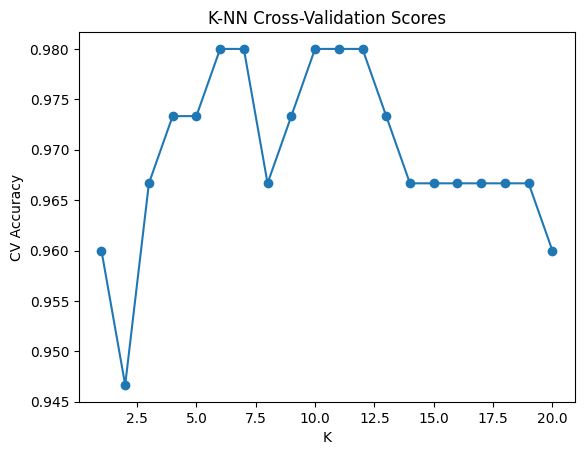

In [8]:
import matplotlib.pyplot as plt

k_range = list(range(1, 21))
cv_scores = [0.96, 0.9466666666666665, 0.9666666666666668, 0.9733333333333334, 0.9733333333333334, 0.9800000000000001, 0.9800000000000001, 0.9666666666666668, 0.9733333333333334, 0.9800000000000001, 0.9800000000000001, 0.9800000000000001, 0.9733333333333334, 0.9666666666666666, 0.9666666666666668, 0.9666666666666668, 0.9666666666666668, 0.9666666666666666, 0.9666666666666668, 0.96]

plt.plot(k_range, cv_scores, marker='o')
plt.xlabel("K")
plt.ylabel("CV Accuracy")
plt.title("K-NN Cross-Validation Scores")
plt.show()

In [9]:
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report










# ■■ Sample email dataset ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
emails = [
'Win a free iPhone now click here', # spam
'Congratulations you won a lottery prize',# spam
'FREE cash prize claim within 24 hours', # spam
'Limited offer buy now get 50 percent off', # spam
'Meeting at 3pm tomorrow please confirm', # ham
'Quarterly report attached for review', # ham
'Can you send me the project files thanks',# ham
'Team lunch tomorrow noon at cafeteria', # ham
'Urgent your account has been suspended', # spam
'Hi please review the attached document', # ham
]






labels = [1,1,1,1,0,0,0,0,1,0] # 1=spam 0=ham







X_train,X_test,y_train,y_test = train_test_split(
emails, labels, test_size=0.3, random_state=42)





# ■■ Pipeline: TF-IDF vectorise -> classify ■■■■■■■■■■■■■■■■■■■■
# TF-IDF: rare informative words get higher weight than common ones
#aas we mentioned we need to convert text to numbers for that we are going to use TF  = Term Frequency
#IDF = Inverse Document Frequency
# alpha=1.0 is Laplace smoothing — prevents zero-probability words



pipe = Pipeline([
('tfidf', TfidfVectorizer(lowercase=True, stop_words='english')),
('nb', MultinomialNB(alpha=1.0)),
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Ham','Spam']))

              precision    recall  f1-score   support

         Ham       0.50      1.00      0.67         1
        Spam       1.00      0.50      0.67         2

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3



In [10]:
# ■■ Inspect learned probabilities ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
nb_model = pipe.named_steps['nb']
vectorizer = pipe.named_steps['tfidf']
feature_names = vectorizer.get_feature_names_out()
import numpy as np

In [11]:
# Top spam words (highest log-probability in spam class)
spam_log_probs = nb_model.feature_log_prob_[1] # class index 1 = spam

top_spam_idx = np.argsort(spam_log_probs)[-10:][::-1]
print('Top spam words:', [feature_names[i] for i in top_spam_idx])

Top spam words: ['free', 'win', 'iphone', 'click', 'percent', 'offer', 'buy', 'limited', '50', 'cash']


In [12]:
# ■■ Predict new emails with confidence ■■■■■■■■■■■■■■■■■■■■■■■■
new = ['  your       its a new job its been great well working this is example for spuerwhjhfv']
for email, pred, prob in zip(new, pipe.predict(new), pipe.predict_proba(new)):
  print(f'[{"SPAM" if pred==1 else "HAM"}] conf={prob[pred]*100:.1f}% {email}')

[HAM] conf=57.1%   your       its a new job its been great well working this is example for spuerwhjhfv


Feature Scaling Code

In [13]:
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [14]:
# ■■ Demo: age vs salary ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
data = pd.DataFrame({'age':[22,35,47,60,18,55,30,42,25,50],
'salary':[25000,50000,75000,95000,18000,88000,42000,65000,30000,72000],
'bought':[0,1,1,1,0,1,0,1,0,1]})
X = data[['age','salary']].values; y = data['bought'].values
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=0)

In [15]:
# ■■ Apply all three scalers ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
ss = StandardScaler()
mm = MinMaxScaler()
rb = RobustScaler()
X_std = ss.fit_transform(X_train) # fit on train, transform train
X_mm = mm.fit_transform(X_train)
X_rb = rb.fit_transform(X_train)
X_test_std = ss.transform(X_test) # only transform test, never fit
print(f'Original Age: {X_train[:,0].min():.0f} to {X_train[:,0].max():.0f}')
print(f'Standard Age: {X_std[:,0].min():.2f} to {X_std[:,0].max():.2f}')
print(f'MinMax Age: {X_mm[:,0].min():.2f} to {X_mm[:,0].max():.2f}')

Original Age: 22 to 60
Standard Age: -1.56 to 1.40
MinMax Age: 0.00 to 1.00


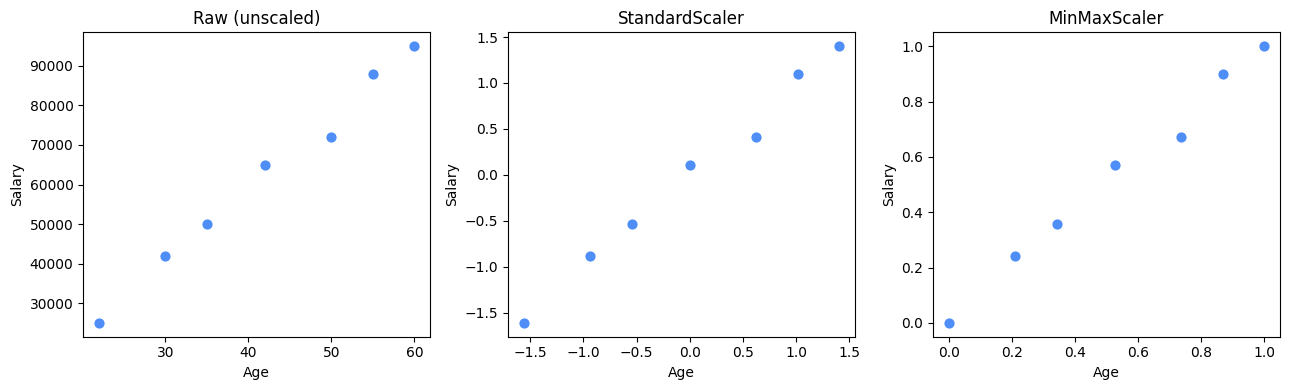

In [16]:
# ■■ Visualise effect of scaling ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
fig, axes = plt.subplots(1,3,figsize=(13,4))
for ax,X_s,title in zip(axes,[X_train,X_std,X_mm],
  ['Raw (unscaled)','StandardScaler','MinMaxScaler']):
  ax.scatter(X_s[:,0],X_s[:,1],c='#4F8EF7',s=70,edgecolor='white')
  ax.set_title(title); ax.set_xlabel('Age'); ax.set_ylabel('Salary')
plt.tight_layout(); plt.show()

In [17]:
# ■■ Effect on KNN decision boundary ■■■■■■■■■■■■■■■■■■■■■■■■■■
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
for name, Xtr, Xte in [('Unscaled', X_train, X_test),
  ('StandardScaler', X_std, X_test_std)]:
  knn = KNeighborsClassifier(n_neighbors=3)
  knn.fit(Xtr, y_train)
  acc = accuracy_score(y_test, knn.predict(Xte))
  print(f'{name:>15} KNN accuracy: {acc:.2f}')

       Unscaled KNN accuracy: 1.00
 StandardScaler KNN accuracy: 1.00


Lab — MNIST Handwritten Digit Recognition

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

In [19]:
import numpy as np
import matplotlib.pyplot as plt
# from sklearn.datasets import fetch_openml # Commenting out problematic import
import tensorflow as tf # Import TensorFlow
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

# ■■ Load MNIST using tf.keras.datasets (more robust) ■■■■■■■■■■■
print('Loading MNIST dataset...')
(X_train_full, y_train_full), (X_test_full, y_test_full) = tf.keras.datasets.mnist.load_data()

# Combine train and test for consistent processing as per original fetch_openml output structure
X = np.concatenate((X_train_full, X_test_full), axis=0)
y = np.concatenate((y_train_full, y_test_full), axis=0)

# Flatten the images from 28x28 to 784 features
X = X.reshape(X.shape[0], -1)

print(f'Full dataset: {X.shape}') # (70000, 784)
# Ensure y is integer type, as fetch_openml does
y = y.astype(int)

Loading MNIST dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Full dataset: (70000, 784)


In [20]:
# ■■ Use 10,000 samples (full set takes ~10 min to predict) ■■■■
X, y = X[:10000], y[:10000]
X_train,X_test,y_train,y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape} Test: {X_test.shape}')

Train: (8000, 784) Test: (2000, 784)


In [21]:
# ■■ Scale pixels 0-255 to standardised values ■■■■■■■■■■■■■■■■■
scaler = StandardScaler()
Xtr_s = scaler.fit_transform(X_train.astype(float))
Xte_s = scaler.transform(X_test.astype(float))

In [22]:
# ■■ Train KNN (ball_tree is faster for high-dim data) ■■■■■■■■■
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean',
algorithm='ball_tree', n_jobs=-1)
knn.fit(Xtr_s, y_train)

KNeighborsClassifier(algorithm='ball_tree', metric='euclidean', n_jobs=-1)

In [ ]:
# ■■ Evaluate ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
y_pred = knn.predict(Xte_s)
print(f'Test Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%')
print(classification_report(y_test, y_pred))

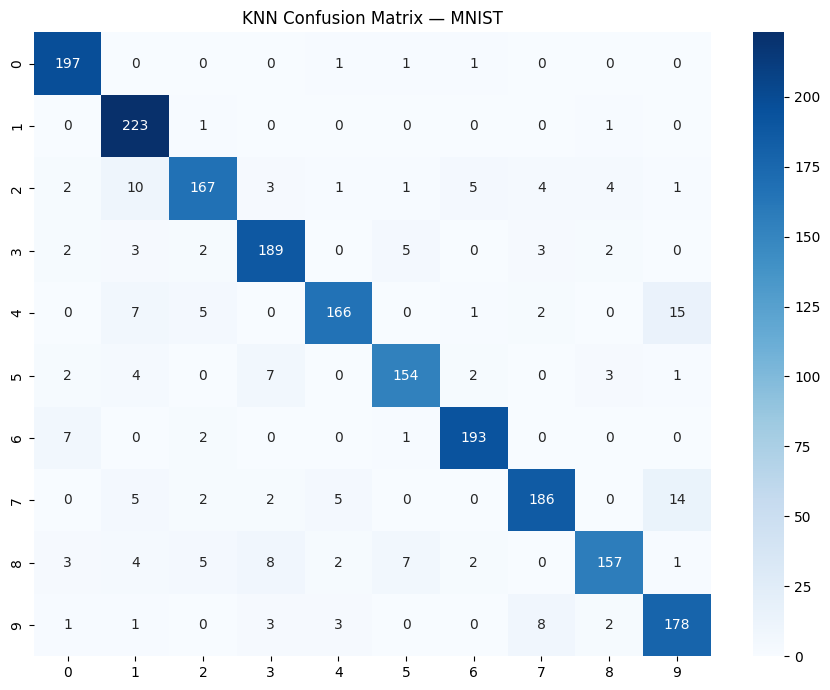

In [24]:
# ■■ Confusion matrix ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
y_pred = knn.predict(Xte_s) # Recalculate y_pred to ensure it's for the MNIST dataset
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=range(10), yticklabels=range(10))
plt.title('KNN Confusion Matrix — MNIST'); plt.tight_layout(); plt.show()

Loading MNIST dataset within cell...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


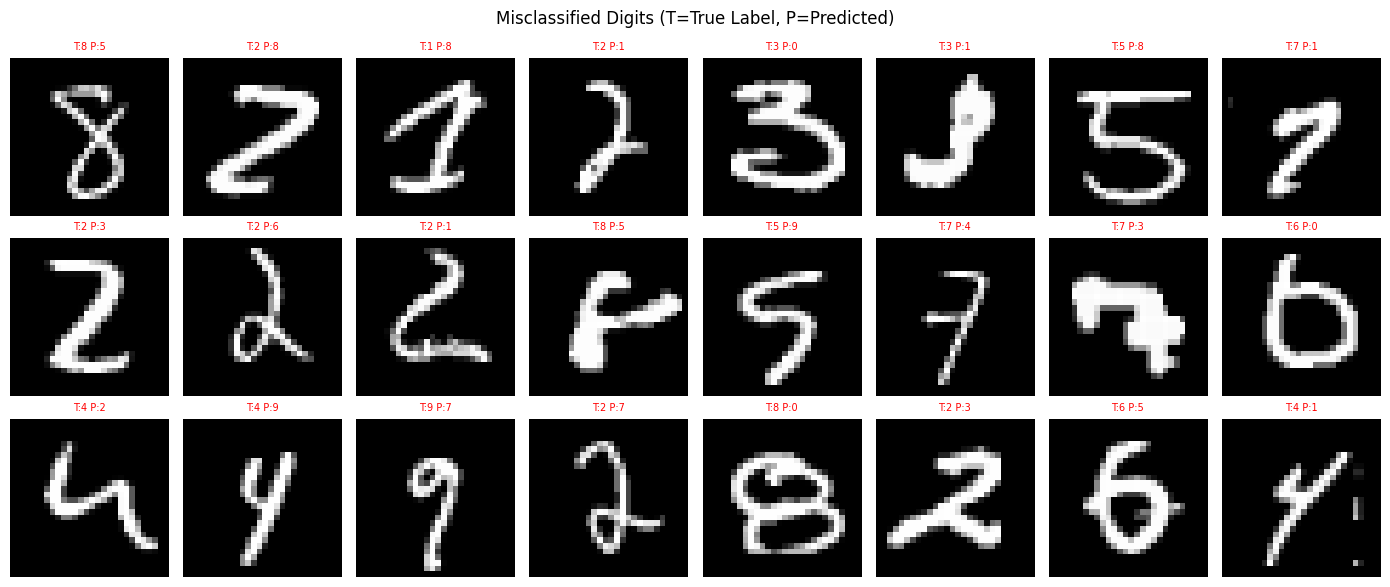

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf # Import TensorFlow

# Re-load MNIST dataset and preprocess to ensure variables are defined
print('Loading MNIST dataset within cell...')
(X_train_full, y_train_full), (X_test_full, y_test_full) = tf.keras.datasets.mnist.load_data()
X = np.concatenate((X_train_full, X_test_full), axis=0)
y = np.concatenate((y_train_full, y_test_full), axis=0)
X = X.reshape(X.shape[0], -1)
y = y.astype(int)

# Use 10,000 samples (as per previous cell)
X_subset, y_subset = X[:10000], y[:10000]
X_train, X_test, y_train, y_test = train_test_split(
X_subset, y_subset, test_size=0.2, random_state=42, stratify=y_subset)

# Scale pixels 0-255 to standardised values (as per previous cell)
scaler = StandardScaler()
Xtr_s = scaler.fit_transform(X_train.astype(float))
Xte_s = scaler.transform(X_test.astype(float))

# ■■ Show misclassified images ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
# Re-initialize and train knn model to ensure it's defined
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean',
algorithm='ball_tree', n_jobs=-1)
knn.fit(Xtr_s, y_train)
y_pred = knn.predict(Xte_s) # Ensure y_pred is defined for this cell
wrong = np.where(y_pred != y_test)[0]
fig, axes = plt.subplots(3,8,figsize=(14,6))
for i,ax in enumerate(axes.flat):
  if i < len(wrong):
    ax.imshow(X_test[wrong[i]].reshape(28,28), cmap='gray')
    ax.set_title(f'T:{y_test[wrong[i]]} P:{y_pred[wrong[i]]}',
    color='red', fontsize=7)
  ax.axis('off')
plt.suptitle('Misclassified Digits (T=True Label, P=Predicted)')
plt.tight_layout(); plt.show()

In [8]:
from sklearn.metrics import accuracy_score
# ■■ Compare K values ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
for k in [1,3,5,7,9]:
  kk = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
  kk.fit(Xtr_s, y_train)
  print(f'K={k} Accuracy={accuracy_score(y_test, kk.predict(Xte_s))*100:.2f}%')

K=1 Accuracy=91.00%
K=3 Accuracy=90.90%
K=5 Accuracy=90.50%
K=7 Accuracy=90.65%
K=9 Accuracy=90.70%
